#  DSAI4201 Project | OryxEye
##  Model Comparison & Selection

## Imports

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import threading
import time
import tensorflow as tf

from google.colab import drive, files
from numpy.linalg import norm

from tensorflow.keras import layers, models
from tensorflow.keras.models import load_model, Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image as keras_image
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

from tensorflow.keras.applications import EfficientNetB0, EfficientNetB3, ResNet50, EfficientNetV2S, MobileNetV2
from tensorflow.keras.applications.efficientnet import preprocess_input as effnet_preprocess
from tensorflow.keras.applications.efficientnet_v2 import preprocess_input as effnetv2_preprocess
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess

## Setup Environment

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Keep-Alive Utility - Background thread to prevent Colab session timeout during extended model training.
def keep_alive():
    while True:
        time.sleep(60)
        print('.', end='', flush=True)

t = threading.Thread(target=keep_alive, daemon=True)
t.start()
print('Keep alive started')

Keep alive started


In [ ]:
#setInterval(() => document.querySelector("colab-connect-button")?.click(), 60000) # run in console

In [ ]:
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
DATA_PATH = '/content/drive/MyDrive/DSAI4201 Project/animals'
SAVE_PATH = '/content/drive/MyDrive/DSAI4201 Project/'

# **Models : MobileNetV2 | EfficientNetB0 & B3 | ResNet50 | EfficientNetV2S**

In [ ]:
def load_data(size, preprocess_fn, batch=32):
    gen = ImageDataGenerator(preprocessing_function=preprocess_fn, validation_split=0.2)
    train = gen.flow_from_directory(DATA_PATH, target_size=(size,size), batch_size=batch, subset='training')
    val   = gen.flow_from_directory(DATA_PATH, target_size=(size,size), batch_size=batch, subset='validation')
    return train, val

In [ ]:
def build_and_train(name, BaseClass, size, preprocess_fn, batch=32):
    print(f'\nTraining {name}:\n')
    train, val = load_data(size, preprocess_fn, batch)
    base = BaseClass(weights='imagenet', include_top=False, input_shape=(size,size,3))
    base.trainable = False
    model = models.Sequential([
        base,
        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(90, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    history = model.fit(train, validation_data=val, epochs=10, verbose=1)

    model.save(f'{SAVE_PATH}{name}.keras')
    print(f'\n\t{name} saved! Val Acc: {round(history.history["val_accuracy"][-1]*100,2)}%\n')

    return model, history, val

In [ ]:
model5, history5, val5 = build_and_train('MobileNetV2',     MobileNetV2,     224, mobilenet_preprocess)
model,  history,  val  = build_and_train('EfficientNetB0',  EfficientNetB0,  224, effnet_preprocess)
model2, history2, val2 = build_and_train('EfficientNetB3',  EfficientNetB3,  300, effnet_preprocess)
model3, history3, val3 = build_and_train('ResNet50',        ResNet50,        224, resnet_preprocess)
model4, history4, val4 = build_and_train('EfficientNetV2S', EfficientNetV2S, 384, effnetv2_preprocess, batch=16)

print('\nAll models trained and saved to Drive')


Training MobileNetV2:

Found 4339 images belonging to 90 classes.
Found 1083 images belonging to 90 classes.
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
.Epoch 1/10
136/136 ━━━━━━━━━━━━━━━━━━━━ 2157s 16s/step - accuracy: 0.5169 - loss: 2.1683 - val_accuracy: 0.7932 - val_loss: 0.7807
Epoch 2/10
136/136 ━━━━━━━━━━━━━━━━━━━━ 49s 358ms/step - accuracy: 0.8380 - loss: 0.5817 - val_accuracy: 0.8264 - val_loss: 0.6402
Epoch 3/10
136/136 ━━━━━━━━━━━━━━━━━━━━ 49s 360ms/step - accuracy: 0.9103 - loss: 0.3213 - val_accuracy: 0.8421 - val_loss: 0.5347
Epoch 4/10
136/136 ━━━━━━━━━━━━━━━━━━━━ 47s 348ms/step - accuracy: 0.9412 - loss: 0.2122 - val_accuracy: 0.8523 - val_loss: 0.5087
Epoch 5/10
136/136 ━━━━━━━━━━━━━━━━━━━━ 49s 357ms/step - accuracy: 0.9631 - loss: 0.1474 - val_accuracy: 0.8615 - val_loss: 0.5037
Epoch 6/10
136/136 ━━━━━━━━━━━━━━━━━━━━ 50s 366ms/step - accuracy: 0.9753 - loss: 0.0983 - val_accuracy: 0.8698 - val_loss: 0.5013
Epoch 7/10
136/136 ━━━━━━━━━━━━━━━━━━━━ 49s 359ms/step

In [ ]:
results = {
    'Model':         ['MobileNetV2', 'EfficientNetB0', 'EfficientNetB3', 'ResNet50', 'EfficientNetV2S'],
    'Input Size':    [224, 224, 300, 224, 384],
    'Train Acc (%)': [round(history5.history['accuracy'][-1]*100, 2),
                      round(history.history['accuracy'][-1]*100,  2),
                      round(history2.history['accuracy'][-1]*100, 2),
                      round(history3.history['accuracy'][-1]*100, 2),
                      round(history4.history['accuracy'][-1]*100, 2)],
    'Val Acc (%)':   [round(history5.history['val_accuracy'][-1]*100, 2),
                      round(history.history['val_accuracy'][-1]*100,  2),
                      round(history2.history['val_accuracy'][-1]*100, 2),
                      round(history3.history['val_accuracy'][-1]*100, 2),
                      round(history4.history['val_accuracy'][-1]*100, 2)],
    'Val Loss':      [round(history5.history['val_loss'][-1], 4),
                      round(history.history['val_loss'][-1],  4),
                      round(history2.history['val_loss'][-1], 4),
                      round(history3.history['val_loss'][-1], 4),
                      round(history4.history['val_loss'][-1], 4)],
}

df = pd.DataFrame(results)
print(df.to_string(index=False))
df.to_csv(f'{SAVE_PATH}results.csv', index=False)
print(f'\nSaved → {SAVE_PATH}results.csv')

          Model  Input Size  Train Acc (%)  Val Acc (%)  Val Loss
    MobileNetV2         224          99.03        87.90    0.4799
 EfficientNetB0         224          99.35        93.35    0.2448
 EfficientNetB3         300          99.22        93.91    0.2152
       ResNet50         224          98.25        87.72    0.4679
EfficientNetV2S         384          98.41        94.92    0.1849

Saved → /content/drive/MyDrive/DSAI4201 Project/results.csv


/tmp/ipykernel_1593/1361723077.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(names, rotation=15, fontsize=8)


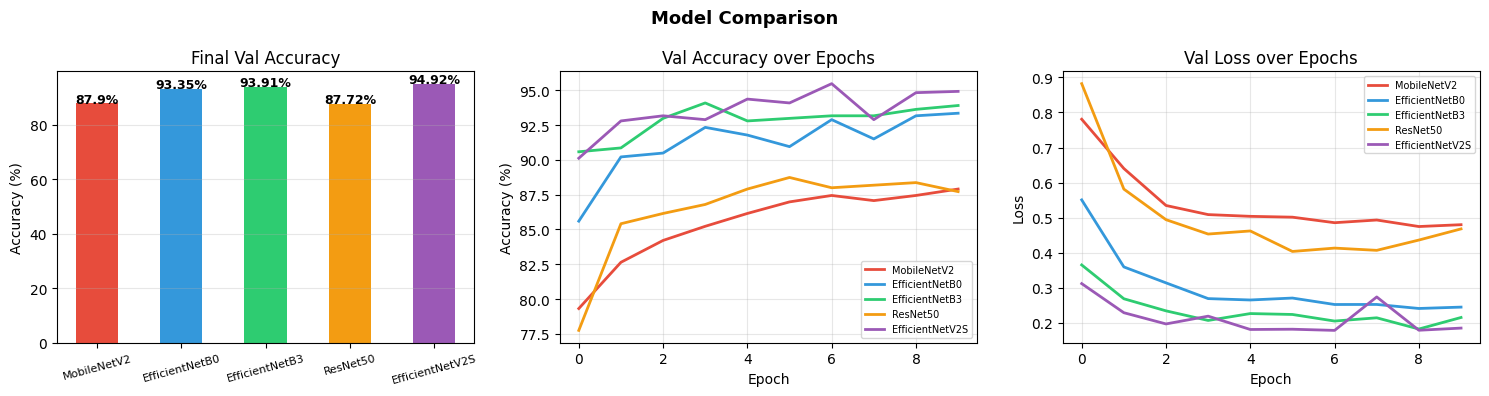

Plot saved → /content/drive/MyDrive/DSAI4201 Project/comparison.png


In [ ]:
histories = [history5, history, history2, history3, history4]
names     = results['Model']
colors    = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Model Comparison', fontsize=13, fontweight='bold')

# Val Accuracy bar
axes[0].bar(names, df['Val Acc (%)'], color=colors, width=0.5)
for i, v in enumerate(df['Val Acc (%)']):
    axes[0].text(i, v + 0.3, f'{v}%', ha='center', fontsize=9, fontweight='bold')
axes[0].set_title('Final Val Accuracy')
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_xticklabels(names, rotation=15, fontsize=8)
axes[0].grid(axis='y', alpha=0.3)

# Val Accuracy over epochs
for h, name, c in zip(histories, names, colors):
    axes[1].plot([v*100 for v in h.history['val_accuracy']],
                 label=name, color=c, linewidth=2)
axes[1].set_title('Val Accuracy over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend(fontsize=7)
axes[1].grid(alpha=0.3)

# Val Loss over epochs
for h, name, c in zip(histories, names, colors):
    axes[2].plot(h.history['val_loss'], label=name, color=c, linewidth=2)
axes[2].set_title('Val Loss over Epochs')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Loss')
axes[2].legend(fontsize=7)
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{SAVE_PATH}comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Plot saved → {SAVE_PATH}comparison.png')

*After comparing the following 5 architectures on the 90-class animal dataset:*

**MobileNetV2,  ResNet50, EfficientNetV2S, EfficientNetB0 & B3**

---

*Following models  were selected as the top two performers for further experimentation.*

 **EfficientNetV2S** (94.92%) & **EfficientNetB3** (93.91%)


*Both models will undergo a 2-phase fine tuning process to maximize validation accuracy while minimizing overfitting.*

 #  EfficientNetV2S vs EfficientNetB3

In [ ]:
gen = ImageDataGenerator(preprocessing_function=effnetv2_preprocess, validation_split=0.2)
train_v2s = gen.flow_from_directory(DATA_PATH, target_size=(384,384), batch_size=16, subset='training', class_mode='categorical')
val_v2s   = gen.flow_from_directory(DATA_PATH, target_size=(384,384), batch_size=16, subset='validation', class_mode='categorical')

Found 4339 images belonging to 90 classes.
Found 1083 images belonging to 90 classes.


In [43]:
gen = ImageDataGenerator(preprocessing_function=effnet_preprocess, validation_split=0.2)
train_b3 = gen.flow_from_directory(DATA_PATH, target_size=(300,300), batch_size=32, subset='training', class_mode='categorical')
val_b3   = gen.flow_from_directory(DATA_PATH, target_size=(300,300), batch_size=32, subset='validation', class_mode='categorical')

Found 4339 images belonging to 90 classes.
Found 1082 images belonging to 90 classes.


#  Fine Tuning — EfficientNetV2S


In [ ]:
base = EfficientNetV2S(weights='imagenet', include_top=False, input_shape=(384,384,3))
base.trainable = False

model_v2s = models.Sequential([
    base,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(90, activation='softmax')
])

model_v2s.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
print('Model ready')

Model ready


In [ ]:
history_warmup = model_v2s.fit(train_v2s, validation_data=val_v2s, epochs=3)
print(f'Warmup Val Acc: {max(history_warmup.history["val_accuracy"])*100:.2f}%')

Epoch 1/3
272/272 ━━━━━━━━━━━━━━━━━━━━ 1942s 7s/step - accuracy: 0.7571 - loss: 1.2794 - val_accuracy: 0.9132 - val_loss: 0.3074
Epoch 2/3
272/272 ━━━━━━━━━━━━━━━━━━━━ 62s 227ms/step - accuracy: 0.9180 - loss: 0.2847 - val_accuracy: 0.9252 - val_loss: 0.2167
Epoch 3/3
272/272 ━━━━━━━━━━━━━━━━━━━━ 63s 230ms/step - accuracy: 0.9394 - loss: 0.1939 - val_accuracy: 0.9363 - val_loss: 0.1917
Warmup Val Acc: 93.63%


In [ ]:
callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True, verbose=1),
    ModelCheckpoint(f'{SAVE_PATH}EfficientNetV2S_finetuned.keras', monitor='val_accuracy', save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=2, min_lr=1e-7, verbose=1)
]

for layer in base.layers[-30:]:
    layer.trainable = True

model_v2s.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_v2s_ft = model_v2s.fit(train_v2s, validation_data=val_v2s, epochs=10, callbacks=callbacks)
print(f'Best Val Acc: {max(history_v2s_ft.history["val_accuracy"])*100:.2f}%')

Epoch 1/10
272/272 ━━━━━━━━━━━━━━━━━━━━ 0s 315ms/step - accuracy: 0.9445 - loss: 0.2280
Epoch 1: val_accuracy improved from None to 0.94183, saving model to /content/drive/MyDrive/DSAI4201 Project/EfficientNetV2S_finetuned.keras

Epoch 1: finished saving model to /content/drive/MyDrive/DSAI4201 Project/EfficientNetV2S_finetuned.keras
272/272 ━━━━━━━━━━━━━━━━━━━━ 194s 486ms/step - accuracy: 0.9532 - loss: 0.2074 - val_accuracy: 0.9418 - val_loss: 0.2030 - learning_rate: 1.0000e-05
Epoch 2/10
272/272 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step - accuracy: 0.9606 - loss: 0.1833
Epoch 2: val_accuracy improved from 0.94183 to 0.94460, saving model to /content/drive/MyDrive/DSAI4201 Project/EfficientNetV2S_finetuned.keras

Epoch 2: finished saving model to /content/drive/MyDrive/DSAI4201 Project/EfficientNetV2S_finetuned.keras
272/272 ━━━━━━━━━━━━━━━━━━━━ 74s 272ms/step - accuracy: 0.9613 - loss: 0.1778 - val_accuracy: 0.9446 - val_loss: 0.1959 - learning_rate: 1.0000e-05
Epoch 3/10
272/272 ━━━━━━━━━

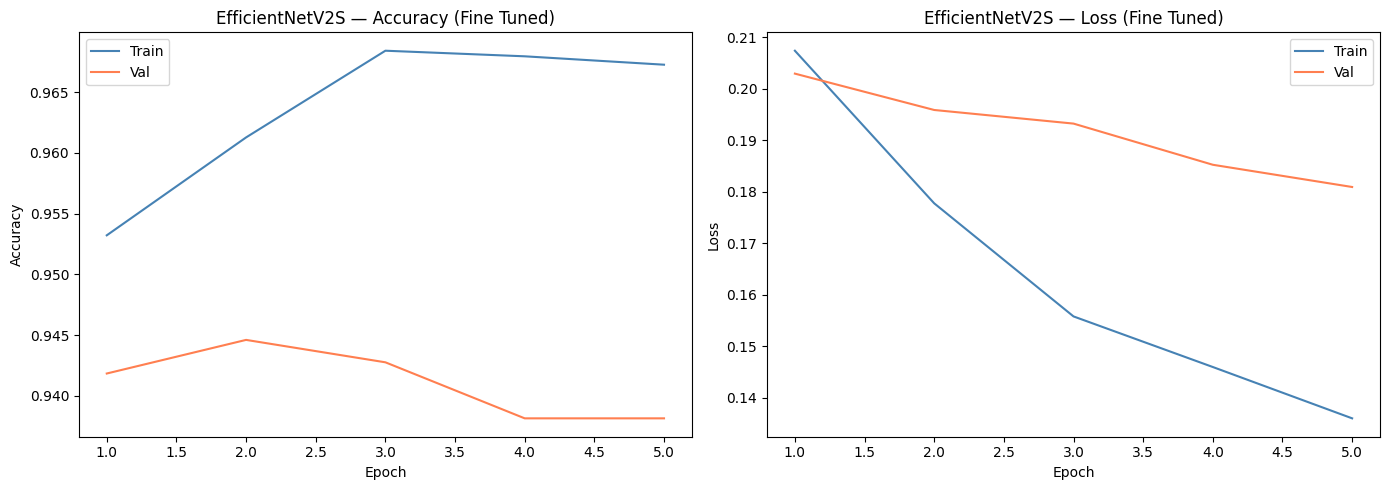

Final Train Accuracy : 96.73%
Final Val Accuracy   : 93.81%
Best  Val Accuracy   : 94.46%
Overfitting Gap      : 2.38%


In [ ]:
os.makedirs(f'{SAVE_PATH}EfficientNetV2S Model/graphs/', exist_ok=True)

epochs = range(1, len(history_v2s_ft.history['accuracy']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(epochs, history_v2s_ft.history['accuracy'],     label='Train', color='steelblue')
axes[0].plot(epochs, history_v2s_ft.history['val_accuracy'], label='Val',   color='coral')
axes[0].set_title('EfficientNetV2S — Accuracy (Fine Tuned)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(epochs, history_v2s_ft.history['loss'],     label='Train', color='steelblue')
axes[1].plot(epochs, history_v2s_ft.history['val_loss'], label='Val',   color='coral')
axes[1].set_title('EfficientNetV2S — Loss (Fine Tuned)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.savefig(f'{SAVE_PATH}EfficientNetV2S Model/graphs/finetuned_curves.png', dpi=150)
plt.show()

print(f'Final Train Accuracy : {history_v2s_ft.history["accuracy"][-1]*100:.2f}%')
print(f'Final Val Accuracy   : {history_v2s_ft.history["val_accuracy"][-1]*100:.2f}%')
print(f'Best  Val Accuracy   : {max(history_v2s_ft.history["val_accuracy"])*100:.2f}%')
gap = (max(history_v2s_ft.history["accuracy"]) - max(history_v2s_ft.history["val_accuracy"])) * 100
print(f'Overfitting Gap      : {gap:.2f}%')

In [ ]:
model_v2s.save(f'{SAVE_PATH}EfficientNetV2S_finetuned_final.keras')
print('Model saved!')

Model saved!


#  Fine Tuning — EfficientNetB3


In [ ]:
base = EfficientNetB3(weights='imagenet', include_top=False, input_shape=(300,300,3))
base.trainable = False

model_b3 = models.Sequential([
    base,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(90, activation='softmax')
])

model_b3.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
print('Model ready')

Model ready


In [ ]:
history_warmup = model_b3.fit(train_b3, validation_data=val_b3, epochs=3)
print(f'Warmup Val Acc: {max(history_warmup.history["val_accuracy"])*100:.2f}%')

Epoch 1/3
136/136 ━━━━━━━━━━━━━━━━━━━━ 226s 1s/step - accuracy: 0.6985 - loss: 1.7174 - val_accuracy: 0.9077 - val_loss: 0.3794
Epoch 2/3
136/136 ━━━━━━━━━━━━━━━━━━━━ 66s 483ms/step - accuracy: 0.9161 - loss: 0.3158 - val_accuracy: 0.9132 - val_loss: 0.2965
Epoch 3/3
136/136 ━━━━━━━━━━━━━━━━━━━━ 61s 449ms/step - accuracy: 0.9514 - loss: 0.1823 - val_accuracy: 0.9243 - val_loss: 0.2358
Warmup Val Acc: 92.43%


In [ ]:
callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=3,
                  restore_best_weights=True, verbose=1),
    ModelCheckpoint(f'{SAVE_PATH}EfficientNetB3_finetuned.keras',
                    monitor='val_accuracy', save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=2,
                      min_lr=1e-7, verbose=1)
]

for layer in base.layers[-30:]:
    layer.trainable = True

model_b3.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_b3 = model_b3.fit(train_b3, validation_data=val_b3, epochs=10, callbacks=callbacks)
print(f'Best Val Acc: {max(history_b3.history["val_accuracy"])*100:.2f}%')

Epoch 1/10
136/136 ━━━━━━━━━━━━━━━━━━━━ 0s 508ms/step - accuracy: 0.9422 - loss: 0.3085
Epoch 1: val_accuracy improved from None to 0.92521, saving model to /content/drive/MyDrive/DSAI4201 Project/EfficientNetB3_finetuned.keras

Epoch 1: finished saving model to /content/drive/MyDrive/DSAI4201 Project/EfficientNetB3_finetuned.keras
136/136 ━━━━━━━━━━━━━━━━━━━━ 150s 761ms/step - accuracy: 0.9463 - loss: 0.2891 - val_accuracy: 0.9252 - val_loss: 0.2803 - learning_rate: 1.0000e-05
Epoch 2/10
136/136 ━━━━━━━━━━━━━━━━━━━━ 0s 330ms/step - accuracy: 0.9463 - loss: 0.2474
Epoch 2: val_accuracy improved from 0.92521 to 0.92705, saving model to /content/drive/MyDrive/DSAI4201 Project/EfficientNetB3_finetuned.keras

Epoch 2: finished saving model to /content/drive/MyDrive/DSAI4201 Project/EfficientNetB3_finetuned.keras
136/136 ━━━━━━━━━━━━━━━━━━━━ 58s 425ms/step - accuracy: 0.9472 - loss: 0.2424 - val_accuracy: 0.9271 - val_loss: 0.2677 - learning_rate: 1.0000e-05
Epoch 3/10
136/136 ━━━━━━━━━━━━━

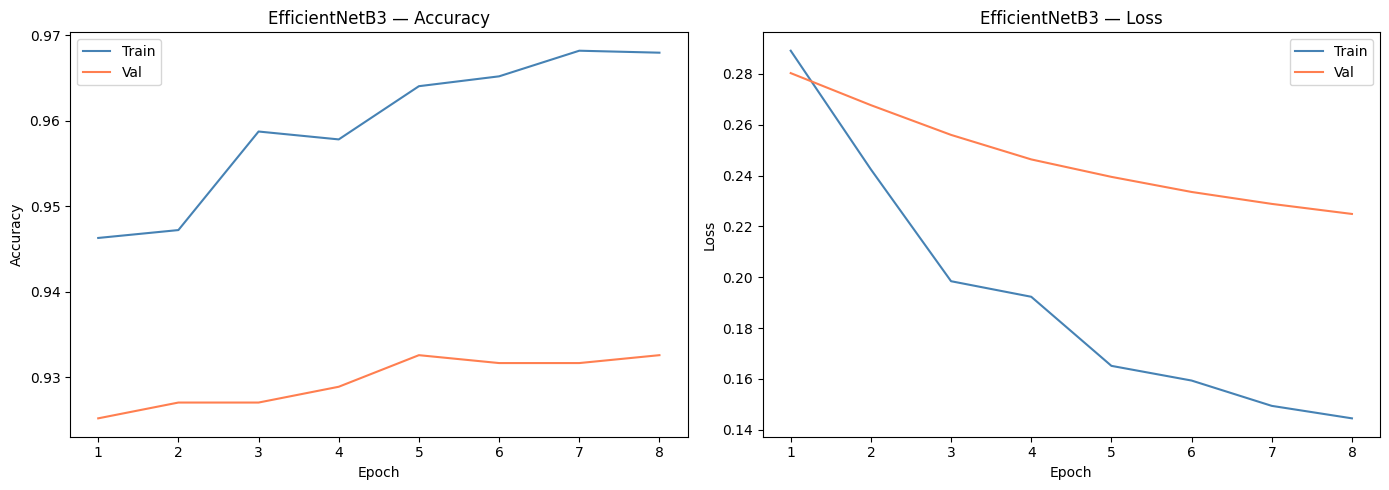

Final Train Accuracy : 96.80%
Final Val Accuracy   : 93.26%
Best  Val Accuracy   : 93.26%
Overfitting Gap      : 3.56%


In [ ]:
os.makedirs(f'{SAVE_PATH}EfficientNetB3 Model/graphs/', exist_ok=True)

epochs = range(1, len(history_b3.history['accuracy']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(epochs, history_b3.history['accuracy'],     label='Train', color='steelblue')
axes[0].plot(epochs, history_b3.history['val_accuracy'], label='Val',   color='coral')
axes[0].set_title('EfficientNetB3 — Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(epochs, history_b3.history['loss'],     label='Train', color='steelblue')
axes[1].plot(epochs, history_b3.history['val_loss'], label='Val',   color='coral')
axes[1].set_title('EfficientNetB3 — Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.savefig(f'{SAVE_PATH}EfficientNetB3 Model/graphs/finetuned_curves_b3.png', dpi=150)
plt.show()

print(f"Final Train Accuracy : {history_b3.history['accuracy'][-1]*100:.2f}%")
print(f"Final Val Accuracy   : {history_b3.history['val_accuracy'][-1]*100:.2f}%")
print(f"Best  Val Accuracy   : {max(history_b3.history['val_accuracy'])*100:.2f}%")
gap = (max(history_b3.history['accuracy']) - max(history_b3.history['val_accuracy'])) * 100
print(f"Overfitting Gap      : {gap:.2f}%")

In [ ]:
model_b3.save(f'{SAVE_PATH}EfficientNetB3_finetuned_final.keras')
print("Model saved ")

Model saved 


 # Comparison EfficientNetB3 vs EfficientNetV2S

In [ ]:
COMPARE_PATH = f'{SAVE_PATH}final comparison EfficientNetB3 vs EfficientNetV2S/'
os.makedirs(COMPARE_PATH, exist_ok=True)

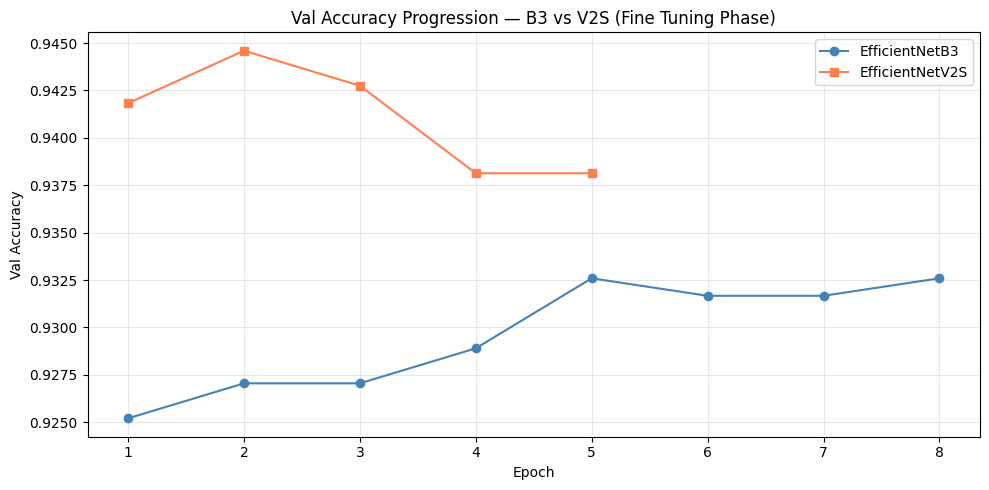

Val accuracy progression saved


In [ ]:
# val accuracy progression
fig, ax = plt.subplots(figsize=(10, 5))
ep_b3  = range(1, len(history_b3.history['accuracy']) + 1)
ep_v2s = range(1, len(history_v2s_ft.history['accuracy']) + 1)
ax.plot(ep_b3,  history_b3.history['val_accuracy'],     'o-', label='EfficientNetB3',  color='steelblue')
ax.plot(ep_v2s, history_v2s_ft.history['val_accuracy'], 's-', label='EfficientNetV2S', color='coral')
ax.set_xlabel('Epoch')
ax.set_ylabel('Val Accuracy')
ax.set_title('Val Accuracy Progression — B3 vs V2S (Fine Tuning Phase)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{COMPARE_PATH}val_accuracy_progression.png', dpi=150)
plt.show()
print('Val accuracy progression saved')

In [ ]:
# full summary CSV
gap_b3  = (max(history_b3.history['accuracy'])     - max(history_b3.history['val_accuracy']))     * 100
gap_v2s = (max(history_v2s_ft.history['accuracy']) - max(history_v2s_ft.history['val_accuracy'])) * 100
full_summary = pd.DataFrame([
    {
        'Model':            'EfficientNetB3',
        'Best Val Acc %':   round(max(history_b3.history['val_accuracy'])*100, 2),
        'Overfitting Gap %':round(gap_b3, 2),
        'Early Stop Epoch': len(history_b3.history['accuracy']),
    },
    {
        'Model':            'EfficientNetV2S',
        'Best Val Acc %':   round(max(history_v2s_ft.history['val_accuracy'])*100, 2),
        'Overfitting Gap %':round(gap_v2s, 2),
        'Early Stop Epoch': len(history_v2s_ft.history['accuracy']),
    },
])
full_summary.to_csv(f'{COMPARE_PATH}full_summary.csv', index=False)
print('\nFull Summary:')
print(full_summary.to_string(index=False))


Full Summary:
          Model  Best Val Acc %  Overfitting Gap %  Early Stop Epoch
 EfficientNetB3           93.26               3.56                 8
EfficientNetV2S           94.46               2.38                 5


*After comparing 5 architectures;* **EfficientNetV2S** *was selected as our final model, achieving the highest validation accuracy of 94.46% with the lowest overfitting gap.*